In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    recall_score
)

from xgboost import XGBClassifier, plot_importance

In [2]:
def find_repo_root(start=None):
    """Walk up from current working directory until the baseline dataset is found."""
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "Dataset" / "students_mental_health_survey_with_burnout_final.csv").exists():
            return cand
    raise FileNotFoundError("Could not locate repository root containing Dataset/students_mental_health_survey_with_burnout_final.csv")

ROOT_PATH = find_repo_root()
ROOT = str(ROOT_PATH)
DATA_PATH = str(ROOT_PATH / "Dataset" / "students_mental_health_survey_with_burnout_final.csv")

df = pd.read_csv(DATA_PATH)
print('Dataset: Dataset/students_mental_health_survey_with_burnout_final.csv')
print('Shape:', df.shape)

Dataset: Dataset/students_mental_health_survey_with_burnout_final.csv
Shape: (10000, 29)


In [3]:
df = pd.read_csv(find_repo_root() / "Dataset" / "students_mental_health_survey_with_burnout_final.csv")
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,...,Residence_Type,burnout_composite_score,burnout,burnout_raw_score,method1_tertiles,method2_wider,method3_very_wide,method4_manual,method5_manual2,method6_kmeans
0,29,Medical,Female,3.69,5,0,3,Good,Low,Average,...,On-Campus,0.199412,0,2.666667,1,1,1,1,1,1
1,24,Business,Female,3.75,1,3,0,Good,Low,Average,...,On-Campus,-0.610848,0,1.333333,0,0,1,0,0,0
2,25,Engineering,Male,3.15,3,2,4,Good,Moderate,Average,...,Off-Campus,0.408598,0,3.000000,2,2,2,1,1,2
3,18,Law,Male,3.97,1,1,5,Poor,Moderate,Average,...,With Family,0.001607,0,2.333333,1,1,1,1,1,1
4,25,Law,Female,3.13,4,3,5,Average,Moderate,Average,...,On-Campus,1.021761,1,4.000000,2,2,2,2,2,2


In [4]:

ENCODING_MAP = {
    "Sleep_Quality": {"Poor": 0, "Average": 1, "Good": 2},
    "Physical_Activity": {"Low": 0, "Moderate": 1, "High": 2},
    "Diet_Quality": {"Good": 0, "Average": 1, "Poor": 2},
    "Social_Support": {"High": 0, "Moderate": 1, "Low": 2},
    "Substance_Use": {"Never": 0, "Unknown": 1, "Occasionally": 2, "Frequently": 3},
    "Counseling_Service_Use": {"Never": 0, "Occasionally": 1, "Frequently": 2},
    "Family_History": {"No": 0, "Yes": 1},
    "Chronic_Illness": {"No": 0, "Yes": 1},
    "Extracurricular_Involvement": {"High": 0, "Moderate": 1, "Low": 2},
}

In [5]:
def preprocess(df):
    drop_cols = [
        "burnout_composite_score",
        "burnout",
        "burnout_raw_score",
        "method1_tertiles",
        "method2_wider",
        "method3_very_wide",
        "method4_manual",
        "method5_manual2",
        "method6_kmeans",
        "Stress_Level",
        "Depression_Score",
        "Anxiety_Score",
    ]
    
    X = df.drop(columns=drop_cols, errors="ignore").copy()

    # Fill missing values
    for c in X.columns:
        if X[c].isnull().any():
            if X[c].dtype == object:
                X[c] = X[c].fillna("Unknown")
            else:
                X[c] = X[c].fillna(X[c].median())

    # Ordinal / binary encoding
    for c, m in ENCODING_MAP.items():
        if c in X.columns:
            X[c] = X[c].astype(str).map(m)

    # One-hot encoding
    cat_cols = ["Course", "Gender", "Relationship_Status", "Residence_Type"]
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X.astype(float)

In [6]:
X = preprocess(df)

y = pd.qcut(
    df["burnout_raw_score"].astype(float),
    q=4,
    labels=[0, 1, 2, 3],
    duplicates="drop"
).astype(int)

print(X.shape)
print(y.value_counts().sort_index())

(10000, 23)
burnout_raw_score
0    3028
1    2760
2    2330
3    1882
Name: count, dtype: int64


In [7]:
print([col for col in X.columns if "burnout" in col.lower()])

[]


In [8]:
print(X.columns)

Index(['Age', 'CGPA', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality',
       'Social_Support', 'Substance_Use', 'Counseling_Service_Use',
       'Family_History', 'Chronic_Illness', 'Financial_Stress',
       'Extracurricular_Involvement', 'Semester_Credit_Load',
       'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others', 'Gender_Male',
       'Relationship_Status_Married', 'Relationship_Status_Single',
       'Residence_Type_On-Campus', 'Residence_Type_With Family'],
      dtype='object')


In [ ]:
#class imbalance handling
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = dict(zip(classes, weights))

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 23)
Test shape: (2000, 23)


In [10]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

#sample weights are used to give more importance to minority classes during training, helping the model learn from imbalanced data.
sample_weights = y.map(class_weights)

xgb.fit(X_train, y_train, sample_weight=sample_weights.loc[y_train.index])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [11]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
kappa = cohen_kappa_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Cohen's Kappa:", round(kappa, 4))

Accuracy: 0.268
Macro F1: 0.2638
Macro Recall: 0.2657
Cohen's Kappa: 0.0189


In [13]:
class_names = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]

print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

Very Low (Q1)       0.34      0.33      0.34       606
     Low (Q2)       0.26      0.22      0.24       552
Moderate (Q3)       0.23      0.24      0.23       466
    High (Q4)       0.23      0.27      0.25       376

     accuracy                           0.27      2000
    macro avg       0.26      0.27      0.26      2000
 weighted avg       0.27      0.27      0.27      2000



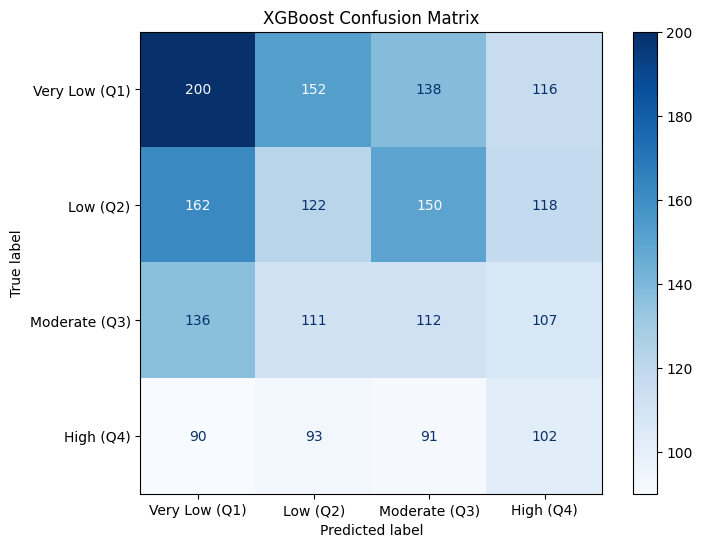

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.show()


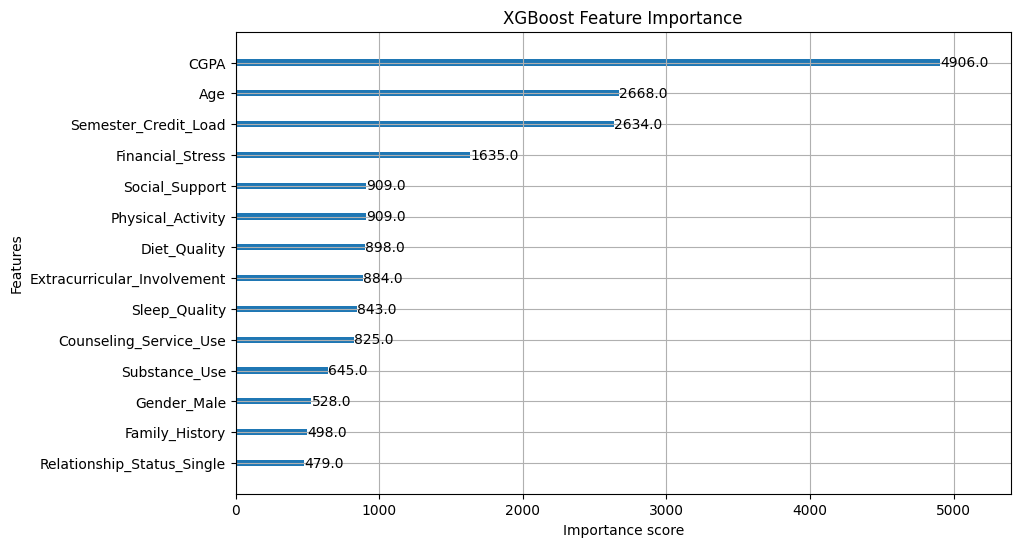

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb, ax=ax, max_num_features=14)
plt.title("XGBoost Feature Importance")
plt.show()

In [31]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_tune = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

grid = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train, sample_weight=sample_weights.loc[y_train.index])

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.26713059785088256


In [29]:
best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)
probs = best_xgb.predict_proba(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
macro_f1_best = f1_score(y_test, y_pred_best, average="macro")
macro_recall_best = recall_score(y_test, y_pred_best, average="macro")
kappa_best = cohen_kappa_score(y_test, y_pred_best)

print("Tuned XGBoost Results")
print("Accuracy:", round(accuracy_best, 4))
print("Macro F1:", round(macro_f1_best, 4))
print("Macro Recall:", round(macro_recall_best, 4))
print("Cohen's Kappa:", round(kappa_best, 4))

Tuned XGBoost Results
Accuracy: 0.274
Macro F1: 0.2638
Macro Recall: 0.2747
Cohen's Kappa: 0.0339


In [32]:
y_train_A = best_xgb.predict(X_train)
y_test_A = best_xgb.predict(X_test)

print("=== Tuned XGBoost ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_A))
print("Test Accuracy:", accuracy_score(y_test, y_test_A))
print("Train Macro F1:", f1_score(y_train, y_train_A, average="macro"))
print("Test Macro F1:", f1_score(y_test, y_test_A, average="macro"))
print("Train Macro Recall:", recall_score(y_train, y_train_A, average="macro"))
print("Test Macro Recall:", recall_score(y_test, y_test_A, average="macro"))
print("Test Kappa:", cohen_kappa_score(y_test, y_test_A))

=== Tuned XGBoost ===
Train Accuracy: 0.375875
Test Accuracy: 0.274
Train Macro F1: 0.3722214514340232
Test Macro F1: 0.2637804130545294
Train Macro Recall: 0.38423636648789544
Test Macro Recall: 0.2746639765634939
Test Kappa: 0.03394756171558133


In [35]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs, multi_class="ovr")
print("Tuned XGBoost ROC AUC (OvR):", round(roc_auc, 4))

Tuned XGBoost ROC AUC (OvR): 0.5228


In [36]:
from sklearn.metrics import log_loss

ll = log_loss(y_test, probs)

print("Tuned XGBoost Log Loss:", round(ll, 4))

Tuned XGBoost Log Loss: 1.3844


XGB FIXED WITHOUT GRID SEARCH

In [37]:
xgb_fixed = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_fixed.fit(X_train, y_train, sample_weight=sample_weights.loc[y_train.index])


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [38]:

y_train_B = xgb_fixed.predict(X_train)
y_test_B = xgb_fixed.predict(X_test)

print("\n=== Fixed Regularized XGBoost ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_B))
print("Test Accuracy:", accuracy_score(y_test, y_test_B))
print("Train Macro F1:", f1_score(y_train, y_train_B, average="macro"))
print("Test Macro F1:", f1_score(y_test, y_test_B, average="macro"))
print("Train Macro Recall:", recall_score(y_train, y_train_B, average="macro"))
print("Test Macro Recall:", recall_score(y_test, y_test_B, average="macro"))
print("Test Kappa:", cohen_kappa_score(y_test, y_test_B))


=== Fixed Regularized XGBoost ===
Train Accuracy: 0.355375
Test Accuracy: 0.2725
Train Macro F1: 0.3486055719062207
Test Macro F1: 0.2592218097108935
Train Macro Recall: 0.3649192057184617
Test Macro Recall: 0.2742294064551548
Test Kappa: 0.033445444804420466


In [20]:
results_df = X_test.copy()

results_df["true_label"] = y_test.values
results_df["predicted_label"] = y_pred_best


for i in range(probs.shape[1]):
    results_df[f"prob_class_{i}"] = probs[:, i]

results_df.to_csv("xgboost_predictions.csv", index=False)

In [21]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Macro Recall", "Kappa", "ROC-AUC OvR", "Log Loss"],
    "Value": [accuracy_best, macro_f1_best, macro_recall_best, kappa_best, roc_auc, ll]
})

metrics_df.to_csv("xgboost_metrics.csv", index=False)

In [22]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_best, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("xgboost_classification_report.csv")

report_df

,precision,recall,f1-score,support
0,0.361702,0.364686,0.363188,606.0000
1,0.274667,0.186594,0.222222,552.0000
2,0.224018,0.208155,0.215795,466.0000
3,0.216867,0.335106,0.263323,376.0000
accuracy,0.273500,0.273500,0.273500,0.2735
macro avg,0.269314,0.273635,0.266132,2000.0000
weighted avg,0.278371,0.273500,0.271164,2000.0000


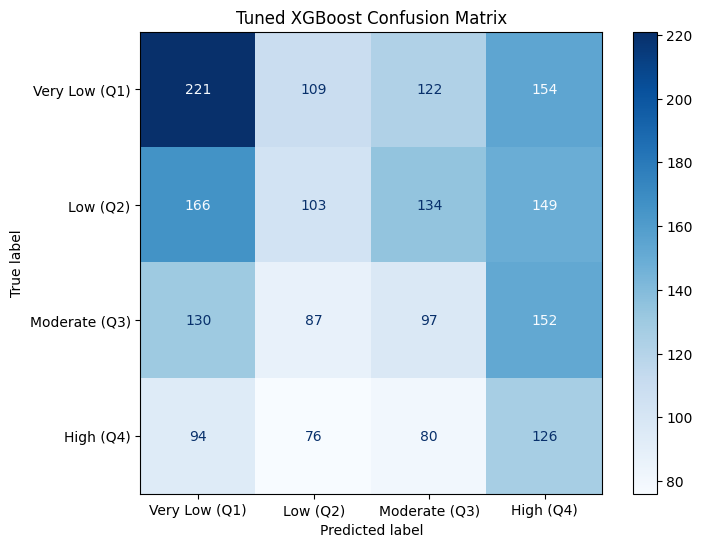

In [24]:
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Tuned XGBoost Confusion Matrix")
plt.savefig("xgboost_confusion_matrix_tuned.png", dpi=300, bbox_inches="tight")

cm_df = pd.DataFrame(
    cm,
    index=disp.display_labels,
    columns=disp.display_labels
)
cm_df.to_csv("xgboost_confusion_matrix_tuned.csv")

plt.show()

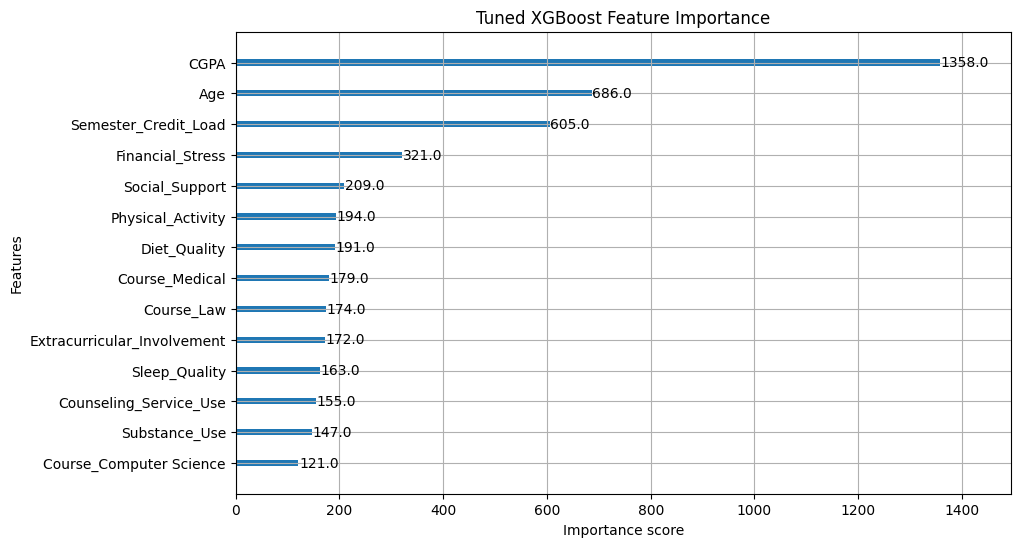

In [25]:
feat_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_imp_df.to_csv("xgboost_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(best_xgb, ax=ax, max_num_features=14)
plt.title("Tuned XGBoost Feature Importance")
plt.savefig("xgboost_feature_importance_tuned.png", dpi=300, bbox_inches="tight")
plt.show()